# Monte Carlo Engine: GBM Path Simulation & Option Pricing

This notebook demonstrates:
1. **GBM path simulation** — sample paths under the risk-neutral measure
2. **Monte Carlo European pricing** — naive MC and antithetic variates
3. **Convergence analysis** — MC price convergence to the Black-Scholes analytical solution
4. **American option pricing** — Longstaff-Schwartz LSMC with convergence and early exercise premium

In [18]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "fin_derivatives"))

import numpy as np
import matplotlib.pyplot as plt

from monte_carlo import simulate_gbm_paths, mc_european_price, lsmc_american_price
from bs_put_call_pricer import call_price, put_price

In [19]:
# Market parameters
S     = 100.0   # spot
K     = 100.0   # strike (ATM)
T     = 1.0     # maturity (years)
r     = 0.05    # risk-free rate
q     = 0.0     # dividend yield
sigma = 0.20    # volatility

## 1. GBM Path Simulation

We simulate sample paths using the exact log-normal solution:

$$S(t) = S_0 \exp\!\Bigl[\bigl(r - q - \tfrac{1}{2}\sigma^2\bigr)t + \sigma\,W(t)\Bigr]$$

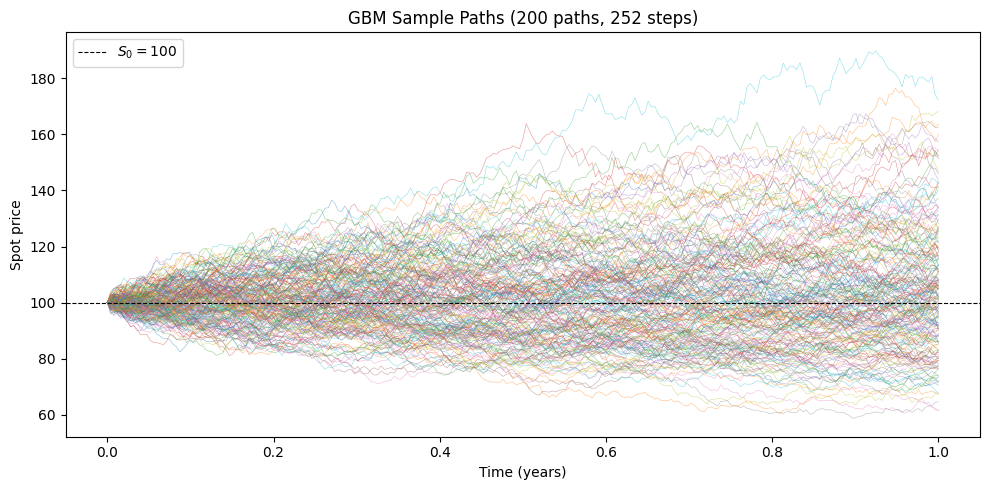

In [20]:
rng = np.random.default_rng(42)
t_grid, paths = simulate_gbm_paths(S, T, r, q, sigma,
                                    n_steps=252, n_paths=200, rng=rng)

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(200):
    ax.plot(t_grid, paths[i], linewidth=0.4, alpha=0.5)
ax.axhline(S, color="black", linestyle="--", linewidth=0.8, label=f"$S_0 = {S:.0f}$")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Spot price")
ax.set_title("GBM Sample Paths (200 paths, 252 steps)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Monte Carlo European Pricing

We compare **naive MC** and **antithetic variates** against the closed-form Black-Scholes price for both calls and puts.

In [21]:
n = 100_000
bs_call = call_price(S, K, T, r, q, sigma)
bs_put  = put_price(S, K, T, r, q, sigma)

results = []
for opt in ("call", "put"):
    bs_ref = bs_call if opt == "call" else bs_put
    for anti in (False, True):
        rng = np.random.default_rng(42)
        mc_px, mc_se = mc_european_price(S, K, T, r, q, sigma, n,
                                         option_type=opt, antithetic=anti, rng=rng)
        label = f"{'Antithetic' if anti else 'Naive':>10s} MC {opt}"
        results.append((label, mc_px, mc_se, bs_ref))

print(f"{'Method':<25s} {'MC Price':>10s} {'Std Err':>10s} {'BS Price':>10s} {'Error':>10s}")
print("-" * 70)
for label, mc_px, mc_se, bs_ref in results:
    print(f"{label:<25s} {mc_px:10.4f} {mc_se:10.4f} {bs_ref:10.4f} {mc_px - bs_ref:+10.4f}")

Method                      MC Price    Std Err   BS Price      Error
----------------------------------------------------------------------
     Naive MC call           10.4205     0.0468    10.4506    -0.0300
Antithetic MC call           10.4763     0.0234    10.4506    +0.0257
     Naive MC put             5.6122     0.0275     5.5735    +0.0387
Antithetic MC put             5.5842     0.0149     5.5735    +0.0107


## 3. Convergence Analysis

We sweep the number of paths from **100 to 100 000** and plot the MC price estimate (with 95% confidence bands) converging to the analytical BS price. Antithetic variates should converge faster (tighter bands).

In [22]:
path_counts = np.unique(np.geomspace(100, 100_000, num=40).astype(int))

# Storage: naive and antithetic, for call
naive_prices, naive_ses = [], []
anti_prices, anti_ses   = [], []

for n in path_counts:
    rng = np.random.default_rng(42)
    px, se = mc_european_price(S, K, T, r, q, sigma, int(n),
                               option_type="call", antithetic=False, rng=rng)
    naive_prices.append(px)
    naive_ses.append(se)

    rng = np.random.default_rng(42)
    px, se = mc_european_price(S, K, T, r, q, sigma, int(n),
                               option_type="call", antithetic=True, rng=rng)
    anti_prices.append(px)
    anti_ses.append(se)

naive_prices = np.array(naive_prices)
naive_ses    = np.array(naive_ses)
anti_prices  = np.array(anti_prices)
anti_ses     = np.array(anti_ses)

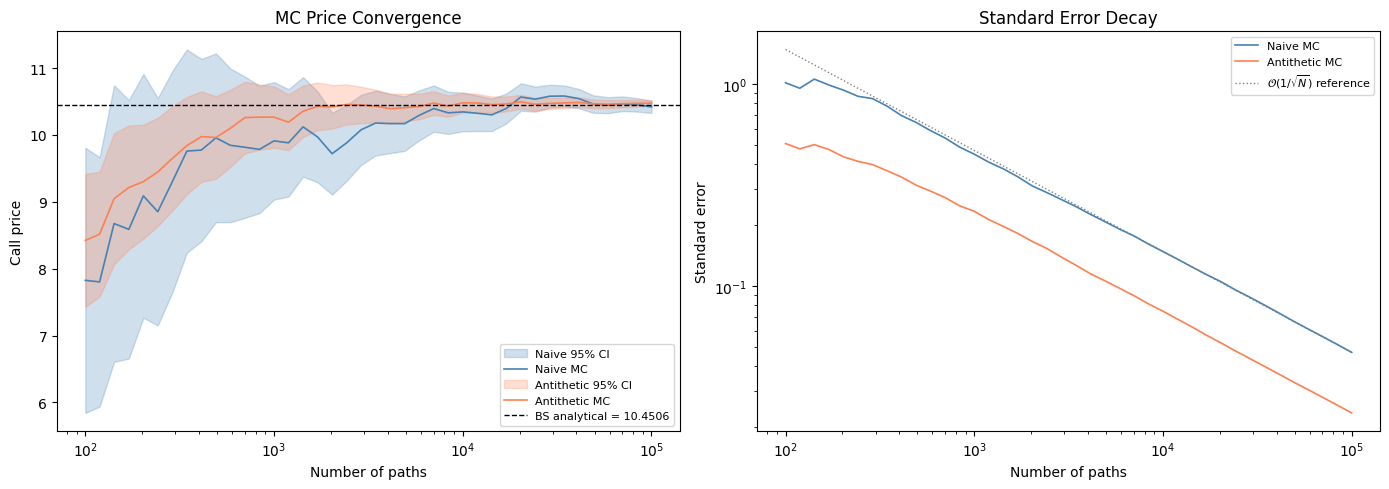

Saved to fin_derivatives/results/mc_convergence.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# --- Left panel: MC price convergence ---
ax = axes[0]
ax.fill_between(path_counts,
                naive_prices - 1.96 * naive_ses,
                naive_prices + 1.96 * naive_ses,
                alpha=0.25, color="steelblue", label="Naive 95% CI")
ax.plot(path_counts, naive_prices, color="steelblue", linewidth=1.2, label="Naive MC")

ax.fill_between(path_counts,
                anti_prices - 1.96 * anti_ses,
                anti_prices + 1.96 * anti_ses,
                alpha=0.25, color="coral", label="Antithetic 95% CI")
ax.plot(path_counts, anti_prices, color="coral", linewidth=1.2, label="Antithetic MC")

ax.axhline(bs_call, color="black", linestyle="--", linewidth=1.0,
           label=f"BS analytical = {bs_call:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Call price")
ax.set_title("MC Price Convergence")
ax.legend(fontsize=8)

# --- Right panel: Standard error decay ---
ax = axes[1]
ax.plot(path_counts, naive_ses, color="steelblue", linewidth=1.2, label="Naive MC")
ax.plot(path_counts, anti_ses, color="coral", linewidth=1.2, label="Antithetic MC")

# theoretical 1/sqrt(N) reference line
ref_se = naive_ses[-1] * np.sqrt(path_counts[-1]) / np.sqrt(path_counts)
ax.plot(path_counts, ref_se, color="grey", linestyle=":", linewidth=1.0,
        label=r"$\mathcal{O}(1/\sqrt{N})$ reference")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Standard error")
ax.set_title("Standard Error Decay")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fin_derivatives/results/mc_convergence.png", dpi=150)
plt.show()
print("Saved to fin_derivatives/results/mc_convergence.png")

## 4. American Option Pricing — Longstaff-Schwartz LSMC

Unlike European options, American options can be exercised at any time before maturity. There is no closed-form solution, making Monte Carlo essential.

The **Longstaff-Schwartz algorithm** works backwards from maturity: at each exercise date it regresses the discounted continuation value against basis functions of the current spot price, then exercises early whenever intrinsic value exceeds the estimated continuation value.

We show:
- **LSMC convergence** — how the American put price stabilises as we increase the number of paths (with 95% CI bands)
- **Early exercise premium across strikes** — the gap between American and European put prices, largest for deep ITM puts

In [24]:
n_steps = 50
eu_put = put_price(S, K, T, r, q, sigma)

# LSMC convergence sweep: 500 to 100k paths
am_path_counts = np.unique(np.geomspace(500, 100_000, num=30).astype(int))
am_prices, am_ses = [], []

for n in am_path_counts:
    rng = np.random.default_rng(42)
    px, se = lsmc_american_price(S, K, T, r, q, sigma, int(n),
                                  n_steps=n_steps, option_type="put",
                                  basis="polynomial", degree=2, rng=rng)
    am_prices.append(px)
    am_ses.append(se)

am_prices = np.array(am_prices)
am_ses    = np.array(am_ses)

# reference price: LSMC with large path count
am_ref = am_prices[-1]

print(f"European put (BS analytical):  {eu_put:.4f}")
print(f"American put (LSMC, 100k):     {am_ref:.4f}")
print(f"Early exercise premium:        {am_ref - eu_put:+.4f}")

European put (BS analytical):  5.5735
American put (LSMC, 100k):     6.0247
Early exercise premium:        +0.4512


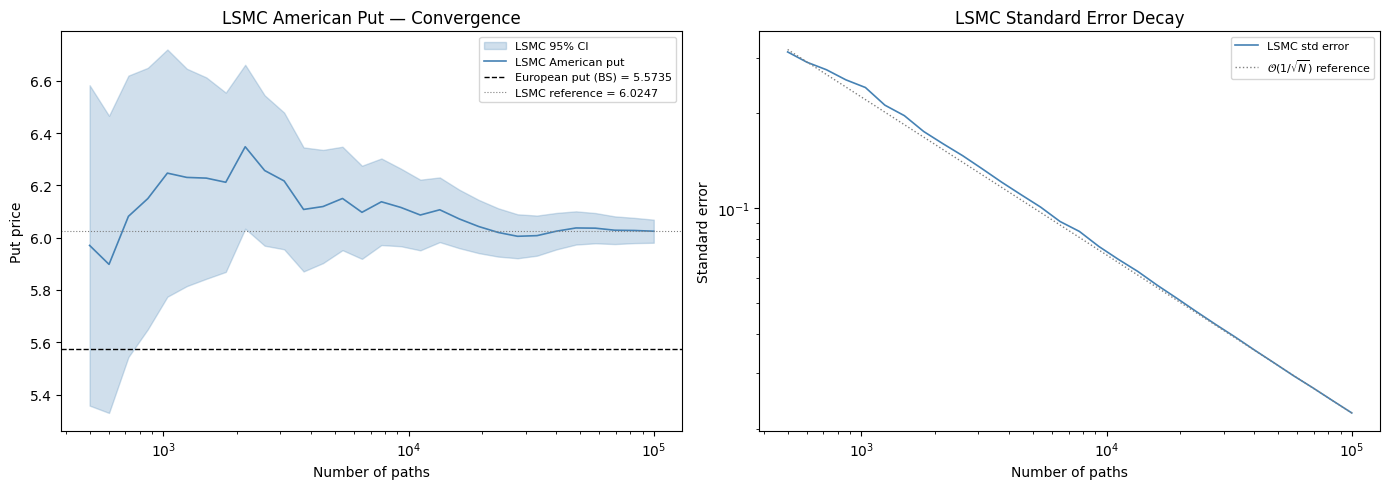

Saved to fin_derivatives/results/lsmc_convergence.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: LSMC convergence ---
ax = axes[0]
ax.fill_between(am_path_counts,
                am_prices - 1.96 * am_ses,
                am_prices + 1.96 * am_ses,
                alpha=0.25, color="steelblue", label="LSMC 95% CI")
ax.plot(am_path_counts, am_prices, color="steelblue", linewidth=1.2,
        label="LSMC American put")
ax.axhline(eu_put, color="black", linestyle="--", linewidth=1.0,
           label=f"European put (BS) = {eu_put:.4f}")
ax.axhline(am_ref, color="grey", linestyle=":", linewidth=0.8,
           label=f"LSMC reference = {am_ref:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Put price")
ax.set_title("LSMC American Put — Convergence")
ax.legend(fontsize=8)

# --- Right panel: SE decay ---
ax = axes[1]
ax.plot(am_path_counts, am_ses, color="steelblue", linewidth=1.2,
        label="LSMC std error")
ref_se = am_ses[-1] * np.sqrt(am_path_counts[-1]) / np.sqrt(am_path_counts)
ax.plot(am_path_counts, ref_se, color="grey", linestyle=":", linewidth=1.0,
        label=r"$\mathcal{O}(1/\sqrt{N})$ reference")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of paths")
ax.set_ylabel("Standard error")
ax.set_title("LSMC Standard Error Decay")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fin_derivatives/results/lsmc_convergence.png", dpi=150)
plt.show()
print("Saved to fin_derivatives/results/lsmc_convergence.png")

### Early exercise premium across strikes

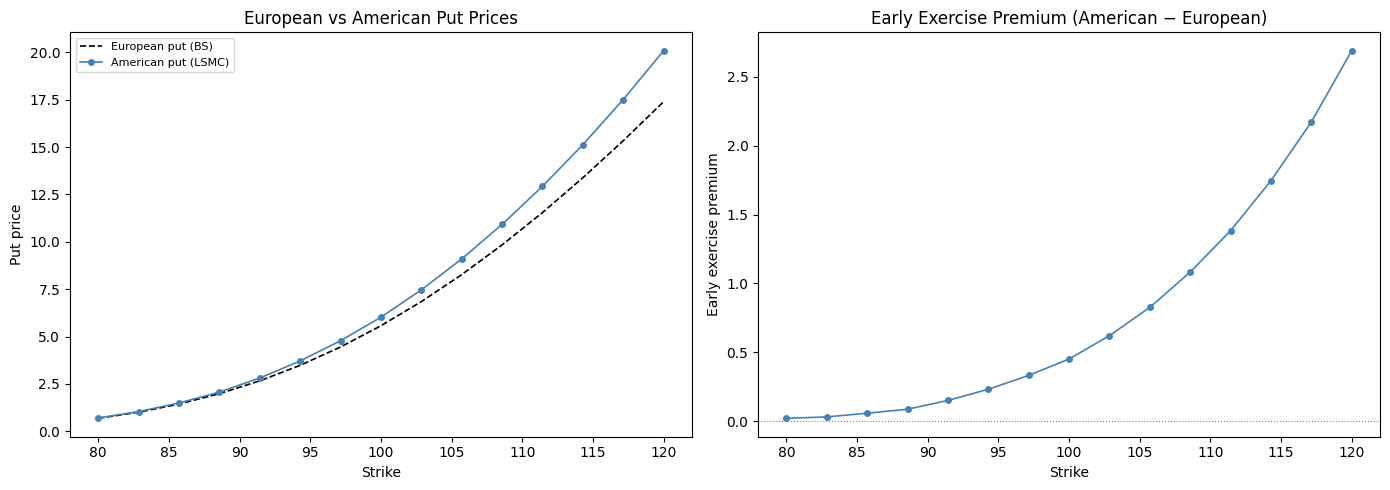

Saved to fin_derivatives/results/american_vs_european.png


In [26]:
strikes = np.linspace(80, 120, 15)
n_paths_am = 100_000

eu_puts = np.array([put_price(S, k, T, r, q, sigma) for k in strikes])
am_puts = []

for k in strikes:
    rng = np.random.default_rng(42)
    px, _ = lsmc_american_price(S, k, T, r, q, sigma, n_paths_am,
                                 n_steps=n_steps, option_type="put",
                                 basis="polynomial", degree=2, rng=rng)
    am_puts.append(px)

am_puts = np.array(am_puts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: prices ---
ax = axes[0]
ax.plot(strikes, eu_puts, "k--", linewidth=1.2, label="European put (BS)")
ax.plot(strikes, am_puts, "o-", color="steelblue", markersize=4,
        linewidth=1.2, label="American put (LSMC)")
ax.set_xlabel("Strike")
ax.set_ylabel("Put price")
ax.set_title("European vs American Put Prices")
ax.legend(fontsize=8)

# --- Right panel: early exercise premium ---
ax = axes[1]
ax.plot(strikes, am_puts - eu_puts, "o-", color="steelblue",
        markersize=4, linewidth=1.2)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
ax.set_xlabel("Strike")
ax.set_ylabel("Early exercise premium")
ax.set_title("Early Exercise Premium (American − European)")

plt.tight_layout()
plt.savefig("fin_derivatives/results/american_vs_european.png", dpi=150)
plt.show()
print("Saved to fin_derivatives/results/american_vs_european.png")